
### Homework: Clustering Analysis on a Customers Dataset
Consider that you possess a dataset of customer information, and your task is to perform customer segmentation on this historical data. Customer segmentation involves dividing a customer base into distinct groups based on shared characteristics. This approach is crucial because it allows a business to target specific groups effectively and optimize the allocation of marketing resources. For instance, one segment might consist of high-profit, low-risk customers—those more likely to make purchases or subscribe to services, whom the business aims to retain. Another segment could be customers from non-profit organizations, among others.

In this assignment, you will perform clustering analysis on the Mall Customers Dataset. This dataset includes the `Age`, `Annual Income`, and `Spending Score` of customers. You will use K-Means and DBSCAN clustering algorithms to segment customers based on their behaviors and traits. The primary objective is to understand customer segments to tailor marketing strategies effectively.

---

#### Step 1: Data Loading and Initial Exploration

**Exercise 1:**
- Load the Mall Customers dataset from the following URL: 'https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/Cust_Segmentation.csv'.
- Use pandas to read the data and display the first few rows. 
- Generate basic statistics of the data using `.describe()`.


In [52]:
import pandas as pd
import io
import requests

# Load the data
url = 'https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/Cust_Segmentation.csv'

s = requests.get(url).content
mall_customers = pd.read_csv(io.StringIO(s.decode('utf-8')))
# Write your code here
print(mall_customers.head())
print(mall_customers.describe())


   Customer Id  Age  Edu  Years Employed  Income  Card Debt  Other Debt  \
0            1   41    2               6      19      0.124       1.073   
1            2   47    1              26     100      4.582       8.218   
2            3   33    2              10      57      6.111       5.802   
3            4   29    2               4      19      0.681       0.516   
4            5   47    1              31     253      9.308       8.908   

   Defaulted Address  DebtIncomeRatio  
0        0.0  NBA001              6.3  
1        0.0  NBA021             12.8  
2        1.0  NBA013             20.9  
3        0.0  NBA009              6.3  
4        0.0  NBA008              7.2  
       Customer Id         Age         Edu  Years Employed      Income  \
count    850.00000  850.000000  850.000000      850.000000  850.000000   
mean     425.50000   35.029412    1.710588        8.565882   46.675294   
std      245.51816    8.041432    0.927784        6.777884   38.543054   
min        1.

#### Step 2: Data Preprocessing

**Exercise 2:**
- As observed, the "Address" field in this dataset is a categorical variable. The k-means algorithm, which relies on Euclidean distance, isn't suitable for categorical data because this type of distance measure doesn't make sense for discrete variables. Therefore, exclude this feature and proceed with the clustering analysis.
- Now  normalize the dataset. But why do we need normalization in the first place? Normalization is a statistical method that helps mathematical-based algorithms to interpret features with different magnitudes and distributions equally. We use __StandardScaler()__ to normalize our dataset.





In [53]:
from sklearn.preprocessing import StandardScaler
import numpy as np
# Write your code here
# exclude Address feature
mall_customers = mall_customers.drop('Address', axis=1)
# check NaN values
print(mall_customers.isnull().sum())
# drop rows of NaN values
mall_customers_dropped = mall_customers.dropna()
# normalize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(mall_customers_dropped)

Customer Id          0
Age                  0
Edu                  0
Years Employed       0
Income               0
Card Debt            0
Other Debt           0
Defaulted          150
DebtIncomeRatio      0
dtype: int64


#### Step 3: Applying K-Means Clustering

**Exercise 3:**
- Apply K-Means clustering on the processed data. Choose a suitable number of clusters (start with `k=3`).
- Fit the model and then predict the cluster labels.
- Add these labels as a new column in the DataFrame and create a new DataFrame.
- Calculate the centroid value of each class.



In [54]:
from sklearn.cluster import KMeans

# Write your code here
# apply K-Means clustering with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
# fit the model
kmeans.fit(scaled_data)
# predict cluster labels
cluster_labels = kmeans.predict(scaled_data)
# add these labels to a new column
df_K = pd.DataFrame(mall_customers_dropped)
df_K['Cluster'] = cluster_labels
# calculate the centroild value of each class
centroids = df_K.groupby('Cluster').mean()

df_K.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio,Cluster
0,1,41,2,6,19,0.124,1.073,0.0,6.3,1
1,2,47,1,26,100,4.582,8.218,0.0,12.8,0
2,3,33,2,10,57,6.111,5.802,1.0,20.9,2
3,4,29,2,4,19,0.681,0.516,0.0,6.3,1
4,5,47,1,31,253,9.308,8.908,0.0,7.2,0


**Exercise 4:**
- Plot the results using a scatter plot. Use `Age` as the x-axis and `Income` as the y-axis. Color the points based on the cluster labels.
- Interpret the plot. What does each cluster seem to represent in terms of customer behavior?


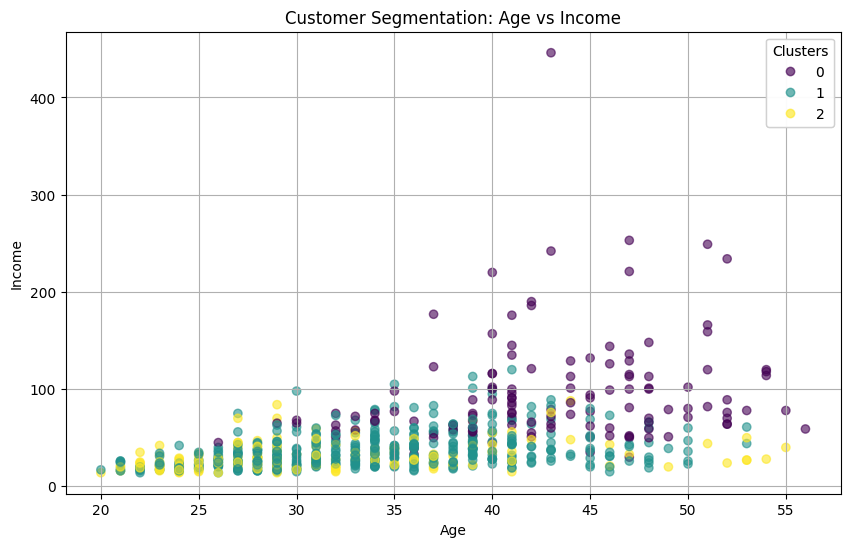

In [55]:
import matplotlib.pyplot as plt

# Write your code here
# create a scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_K['Age'], df_K['Income'], c=df_K['Cluster'], cmap='viridis', alpha=0.6)

# adding title and labels
plt.title('Customer Segmentation: Age vs Income')
plt.xlabel('Age')
plt.ylabel('Income')

# create a legend
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)

plt.grid()
plt.show()



cluster 2 could represent low income customers, mostly young.

cluster 1 could represent middle income customers, mostly middle-aged.

cluster 0 could represent high income customers, basically older people.

#### Step 4: Applying DBSCAN Clustering

**Exercise 5:**
- Apply DBSCAN to the same dataset. Start with `eps=0.5` and `min_samples=5`.
- Fit the model and then predict the cluster labels.
- Determine the count of predicted classes. Adjust 'eps' and 'min_samples' to attain a total of three classes.
- Add these labels as a new column in your DataFrame and create a new DataFrame.

In [56]:
from sklearn.cluster import DBSCAN
# Write your code here
import numpy as np
# start with eps=0.5, min_samples=5
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)
unique_clusters = set(dbscan_labels)
print(len(unique_clusters))
# adjust to three classes
for eps in np.arange(0.1,1.1,0.1):
    for min_samples in (2,11,1):
        # Apply DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(scaled_data)
        unique_clusters = set(labels)
        if len(unique_clusters) == 3 :
            print(round(eps,1), min_samples)
# choose one and add to a new dataframe            
dbscan = DBSCAN(eps=0.8, min_samples=11)
dbscan_labels = dbscan.fit_predict(scaled_data)
df_D = pd.DataFrame(mall_customers_dropped)
df_D['Cluster'] = dbscan_labels


1
0.8 11
0.9 11




#### Submission Instructions
Please submit your finished Jupyter Notebook with all exercises fully completed. Make sure to include comments in your code cells to clarify your thought process and results. Below each corresponding exercise, add your discussions in a "Markdown" section within this file.


**Exercise 6:**
- Plot the results using the same scatter plot setup as in Exercise 4.
- Compare the results with K-Means. How does DBSCAN differ in terms of cluster formation?

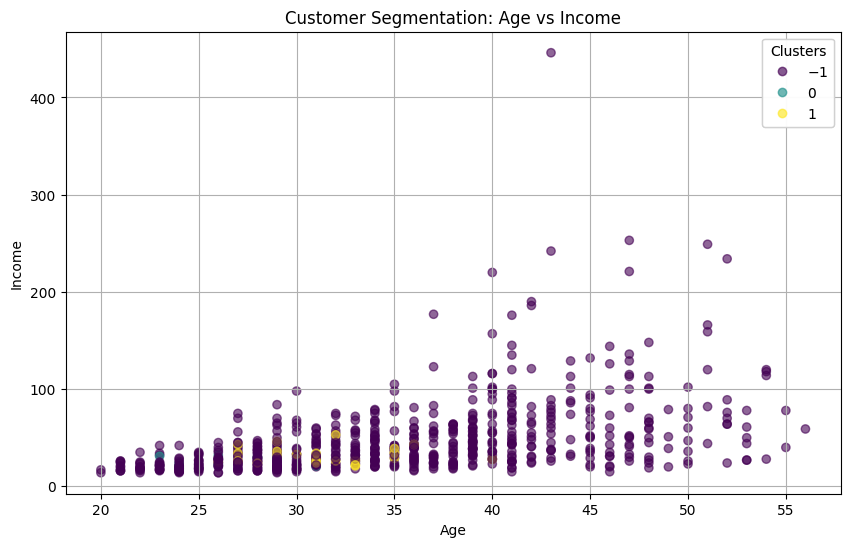

In [57]:
# Write your code here
# create a scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_D['Age'], df_D['Income'], c=df_D['Cluster'], cmap='viridis', alpha=0.6)

# adding title and labels
plt.title('Customer Segmentation: Age vs Income')
plt.xlabel('Age')
plt.ylabel('Income')

# create a legend
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)

plt.grid()
plt.show()

DBSCAN plot doesn't seem to distinguish three classes apparently. K-means plot is clearer and more effective.

#### Step 5: Evaluation and Interpretation

**Exercise 7:**
- Calculate and compare the silhouette scores for both K-Means and DBSCAN.
- Discuss the strengths and weaknesses of each clustering method based on the dataset and the results obtained.

In [58]:
from sklearn.metrics import silhouette_score

# Write your code here
# K-Means silhouette score
kmeans_silhouette = silhouette_score(scaled_data, df_K['Cluster'])
print('K-Means Silhouette Score:' + str(round(kmeans_silhouette,2)))
# DBSCAN silhouette score
dbscan_silhouette = silhouette_score(scaled_data, df_D['Cluster'])
print('DBSCAN Silhouette Score:' + str(round(dbscan_silhouette,2)))

K-Means Silhouette Score:0.23
DBSCAN Silhouette Score:-0.23


K-means silhouette score is postive which is more effective. DBSCAN silhoutte score is negative, bad performance.

In the customer dataset, the behavior of customers is typical and highly predictable, K-means method operates better. It's good for spherical clusters and can be easily interpreted. Its weakness can be it needs a predefined assumption. If the dataset is complicated, the optimal number of clusters is hard to be assumed.

While DBSCAN doen's need predefined clusters, can handle noise well and can discover clusters of arbitrary shapes, making it suitable for datasets where clusters may not be spherical. Its weakness includes parameter sensitivity, may lead to either too many clusters or merging of distinct clusters. 



#### Submission Instructions
Please submit your finished Jupyter Notebook with all exercises fully completed. Make sure to include comments in your code cells to clarify your thought process and results. Below each corresponding exercise, add your discussions in a "Markdown" section within this file.
